<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 50%,#312e81 100%);padding:40px;border-radius:14px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;">

<h1 style="margin:0;font-size:42px;letter-spacing:1px;">Image Processing & Filtering</h1>
<h3 style="margin:8px 0 18px 0;font-weight:300;opacity:0.9;">Notebook 03 - Convolution, Filters, Edges & Morphology</h3>

<p style="font-size:15px;opacity:0.85;margin:0;">Computer Vision Series - for AI Students & AI Engineers</p>
<p style="font-size:13px;opacity:0.7;margin-top:6px;">Prereqs: Notebooks 01 (Foundations) & 02 (NumPy/OpenCV Core)</p>

</div>

---

> **Note:** All content in this notebook (text, structure, code) is for educational purposes. Always verify critical facts and run code in your own environment.

---

### Where we are in the series

| # | Notebook | Status |
|---|---|---|
| 01 | Foundations, History & Modern Toolkit | Done |
| 02 | Image Fundamentals & NumPy/OpenCV Core | Done |
| **03** | **Image Processing & Filtering** | *You are here* |
| 04 | Feature Detection (SIFT, ORB, Harris) | upcoming |
| 05 | Classical ML for Vision | upcoming |
| 06+ | Deep Learning, Detection, Segmentation, Generative, VLMs | upcoming |

---

### What you'll master in this notebook

1. **Convolution** - the single operation behind every classical filter and every CNN
2. **Smoothing filters** - Mean, Gaussian, Median, Bilateral (with clear *when-to-use* rules)
3. **Sharpening** - direct kernels and the photographer's "unsharp mask" trick
4. **Edge detection in depth** - Sobel, Scharr, Laplacian, Canny (gold standard)
5. **Morphology** - erode, dilate, open, close, top-hat - the binary-image surgery toolkit
6. **Frequency-domain filtering** - see images through the FFT lens
7. **Capstone** - build a real license-plate cleanup pipeline

> Every section is runnable and offline - synthetic images and procedural noise.


## 1. Convolution - The One Operation That Started It All

> *If you understand convolution deeply, you understand both classical CV and the inner workings of every CNN.*

### The math (clean version)

Given an image `I` and a kernel `K` (small odd-sized matrix, e.g., 3x3), the output at pixel `(y, x)` is:

$$
O(y, x) = \sum_{i,j} I(y+i, x+j) \cdot K(i, j)
$$

In plain English: slide the kernel over the image; at each position, multiply elementwise and sum.

### Convolution vs. Cross-correlation

- True mathematical convolution flips the kernel.
- What CV libraries (and CNNs) call "convolution" is actually cross-correlation (no flip).
- For symmetric kernels (Gaussian, box), the two are identical - nobody worries about it in practice.

### The 4 things a kernel can do

| Kernel pattern | Effect |
|---|---|
| All positive, sums to 1 | Smoothing (low-pass) |
| Center positive, neighbors negative | Sharpening / edges (high-pass) |
| Asymmetric (positive one side, negative other) | Directional gradient |
| Sums to 0 | Pure edge detector (no DC component) |


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# A tiny demonstration: convolution by hand on a 6x6 image with a 3x3 kernel
np.random.seed(0)
img = np.array([
    [10, 10, 10, 80, 80, 80],
    [10, 10, 10, 80, 80, 80],
    [10, 10, 10, 80, 80, 80],
    [10, 10, 10, 80, 80, 80],
    [10, 10, 10, 80, 80, 80],
    [10, 10, 10, 80, 80, 80],
], dtype=np.float32)

# Sobel-X kernel: detects vertical edges (horizontal gradient)
K = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float32)

# Apply convolution at every interior pixel manually
out = np.zeros_like(img)
for y in range(1, img.shape[0]-1):
    for x in range(1, img.shape[1]-1):
        region = img[y-1:y+2, x-1:x+2]
        out[y, x] = (region * K).sum()

print("Input image:")
print(img.astype(int))
print("\nKernel (Sobel-X):")
print(K.astype(int))
print("\nOutput:")
print(out.astype(int))

print("\nNotice the big response at column 3 - that's exactly where the vertical edge sits.")

Input image:
[[10 10 10 80 80 80]
 [10 10 10 80 80 80]
 [10 10 10 80 80 80]
 [10 10 10 80 80 80]
 [10 10 10 80 80 80]
 [10 10 10 80 80 80]]

Kernel (Sobel-X):
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Output:
[[  0   0   0   0   0   0]
 [  0   0 280 280   0   0]
 [  0   0 280 280   0   0]
 [  0   0 280 280   0   0]
 [  0   0 280 280   0   0]
 [  0   0   0   0   0   0]]

Notice the big response at column 3 - that's exactly where the vertical edge sits.


## 2. Smoothing Filters - Removing Noise

Smoothing filters reduce high-frequency content (noise, fine texture) while preserving the underlying scene. The four you must know:

| Filter | Math | Edge-preserving? | Best for |
|---|---|---|---|
| **Mean (Box)** | Average of neighborhood | No | Quick blur, prototyping |
| **Gaussian** | Weighted by Gaussian | No | General-purpose smoothing - the default |
| **Median** | Median of neighborhood | Partial | Salt-and-pepper noise (impulse noise) |
| **Bilateral** | Gaussian x range filter | Yes | Smoothing while keeping edges sharp (e.g., skin smoothing) |

### Kernel size rule of thumb

- Larger kernel = stronger smoothing = more detail lost.
- Use odd sizes (3, 5, 7, 9...) so there's a well-defined center pixel.
- Gaussian: kernel size approx. `6*sigma + 1` covers >99% of the bell curve.


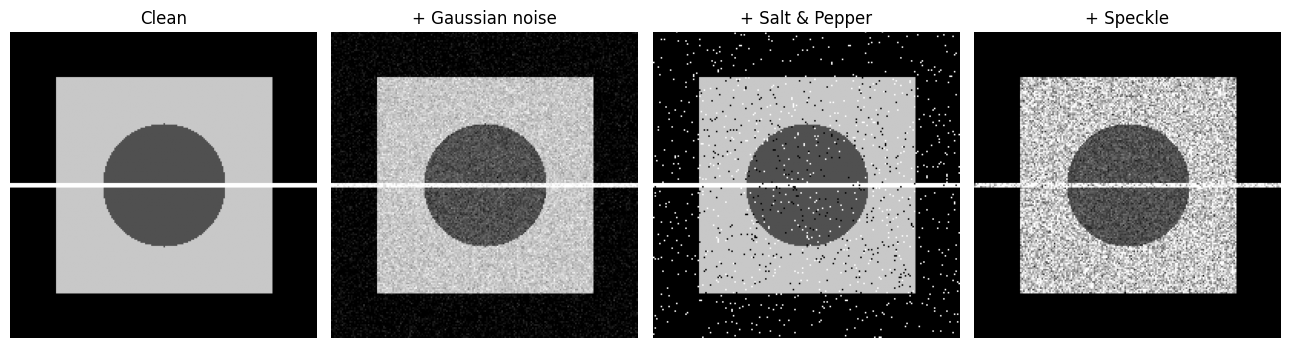

In [2]:
# Build a clean test image, then add 3 different kinds of noise
H, W = 200, 200
clean = np.zeros((H, W), dtype=np.uint8)
cv2.rectangle(clean, (30, 30), (170, 170), 200, -1)
cv2.circle(clean, (100, 100), 40, 80, -1)
cv2.line(clean, (0, 100), (W-1, 100), 255, 2)

# (a) Gaussian noise - sensor noise, low-light
gauss_noise = np.random.normal(0, 18, clean.shape)
img_gauss = np.clip(clean + gauss_noise, 0, 255).astype(np.uint8)

# (b) Salt-and-pepper noise - dead pixels, transmission errors
sp = clean.copy()
n_pixels = int(0.04 * sp.size)
ys = np.random.randint(0, H, n_pixels)
xs = np.random.randint(0, W, n_pixels)
sp[ys[:n_pixels//2], xs[:n_pixels//2]] = 0     # pepper
sp[ys[n_pixels//2:], xs[n_pixels//2:]] = 255   # salt

# (c) Speckle noise - multiplicative (radar, ultrasound)
speck = np.clip(clean + clean * np.random.normal(0, 0.25, clean.shape), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
titles = ["Clean", "+ Gaussian noise", "+ Salt & Pepper", "+ Speckle"]
images = [clean, img_gauss, sp, speck]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

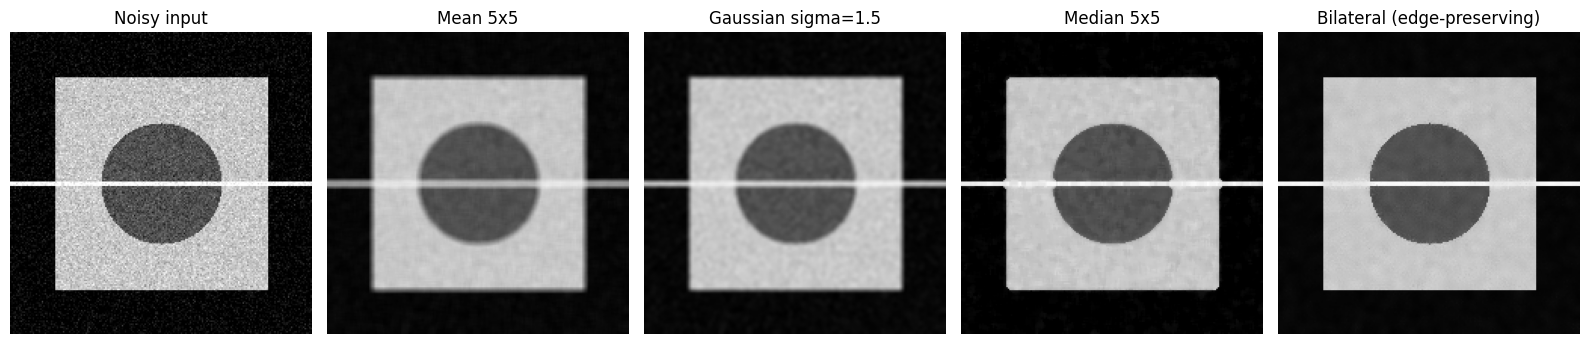

In [3]:
# Apply all 4 smoothing filters to the GAUSSIAN-noisy image and compare
mean_filter = cv2.blur(img_gauss, (5, 5))
gauss_filter = cv2.GaussianBlur(img_gauss, (5, 5), sigmaX=1.5)
median_filter = cv2.medianBlur(img_gauss, 5)
bilat_filter = cv2.bilateralFilter(img_gauss, d=9, sigmaColor=50, sigmaSpace=50)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
images = [img_gauss, mean_filter, gauss_filter, median_filter, bilat_filter]
titles = [
    "Noisy input", "Mean 5x5", "Gaussian sigma=1.5",
    "Median 5x5", "Bilateral (edge-preserving)",
]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

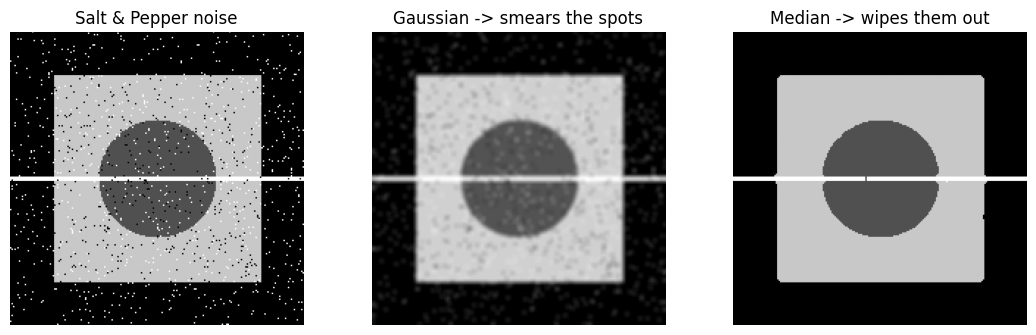

Median replaces each pixel with the MEDIAN of its neighborhood - outliers get ignored.
For salt-and-pepper noise, this is roughly magic.


In [4]:
# The killer demo: median filter on SALT & PEPPER (where Gaussian fails badly)
gauss_on_sp = cv2.GaussianBlur(sp, (5, 5), 1.5)
median_on_sp = cv2.medianBlur(sp, 5)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
axes[0].imshow(sp, cmap="gray")
axes[0].set_title("Salt & Pepper noise")
axes[1].imshow(gauss_on_sp, cmap="gray")
axes[1].set_title("Gaussian -> smears the spots")
axes[2].imshow(median_on_sp, cmap="gray")
axes[2].set_title("Median -> wipes them out")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Median replaces each pixel with the MEDIAN of its neighborhood - outliers get ignored.")
print("For salt-and-pepper noise, this is roughly magic.")

### 2.1 - Bilateral filter: smooth flat regions, keep edges sharp

This is the filter behind "skin smoothing" in phone cameras. The trick: weight neighbors by both spatial distance and intensity similarity. Pixels across an edge are far away in intensity even if close in space, so they get downweighted.

```
weight(i, j) = G_spatial(distance) * G_range(|I_i - I_j|)
```


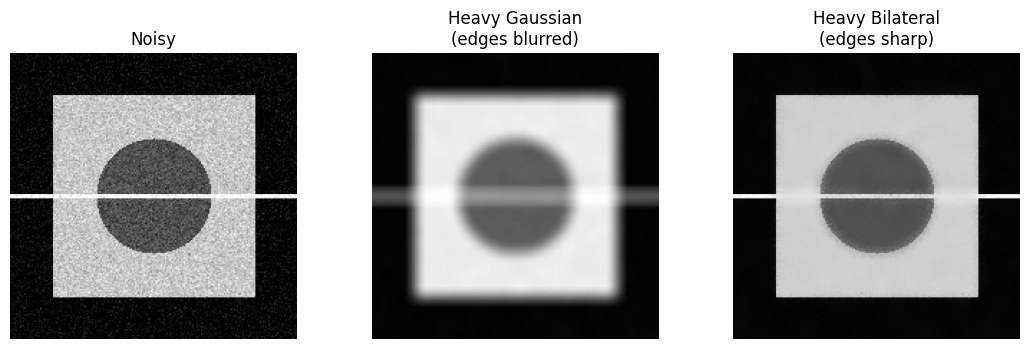

In [5]:
# Show why bilateral wins: aggressive smoothing without losing edges
gauss_strong = cv2.GaussianBlur(img_gauss, (15, 15), 5)
bilat_strong = cv2.bilateralFilter(img_gauss, d=15, sigmaColor=80, sigmaSpace=80)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(img_gauss, cmap="gray")
axes[0].set_title("Noisy")
axes[1].imshow(gauss_strong, cmap="gray")
axes[1].set_title("Heavy Gaussian\n(edges blurred)")
axes[2].imshow(bilat_strong, cmap="gray")
axes[2].set_title("Heavy Bilateral\n(edges sharp)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Sharpening - Boosting the High Frequencies

Sharpening is the opposite of smoothing: amplify rapid intensity changes (= edges).

### Two ways to do it

1. **Direct kernel** - apply a high-pass filter like:

$$\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

The center weight (5) > sum of negatives (4), so the kernel sums to 1 -> preserves overall brightness.

2. **Unsharp masking** (the photographer's method, despite the confusing name):

```
sharpened = original + amount * (original - blurred)
```

Subtracting the blurred version isolates the high frequencies; adding them back boosts them. It's called "unsharp" because we use an unsharp (blurred) version to compute the boost.


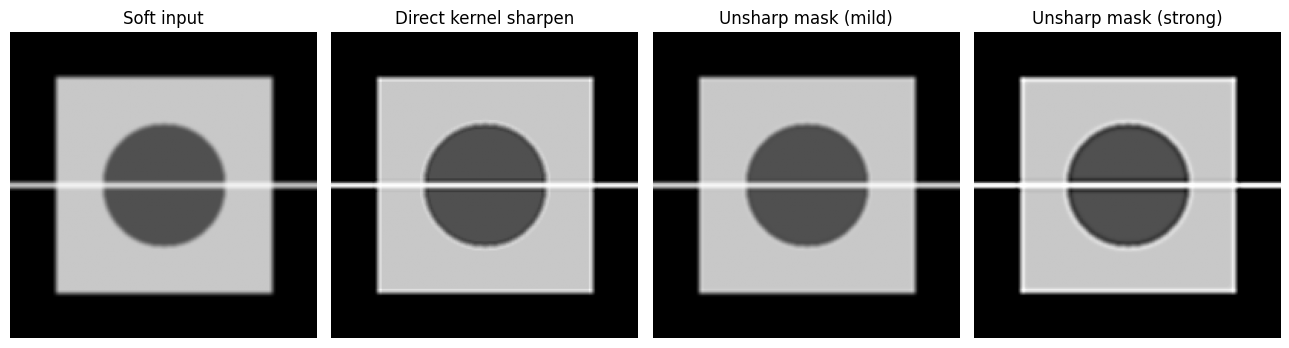

Sharpening also amplifies noise. ALWAYS denoise *before* sharpening.


In [6]:
# Make a slightly soft image so we have something to sharpen
soft = cv2.GaussianBlur(clean, (5, 5), 1.5).astype(np.uint8)

# (a) Direct kernel sharpening
sharp_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0],
], dtype=np.float32)
sharp_direct = cv2.filter2D(soft, -1, sharp_kernel)

# (b) Unsharp masking - amount controls strength
def unsharp_mask(img, sigma=1.5, amount=1.5):
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

unsharp_mild = unsharp_mask(soft, sigma=1.0, amount=0.8)
unsharp_strong = unsharp_mask(soft, sigma=1.5, amount=2.0)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
images = [soft, sharp_direct, unsharp_mild, unsharp_strong]
titles = [
    "Soft input", "Direct kernel sharpen",
    "Unsharp mask (mild)", "Unsharp mask (strong)",
]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Sharpening also amplifies noise. ALWAYS denoise *before* sharpening.")

## 4. Edge Detection - From Sobel to Canny

An edge is a place where intensity changes sharply. Mathematically, it's where the gradient magnitude is large.

### The four classics

| Detector | Year | Order | Notes |
|---|---|---|---|
| **Sobel** | 1968 | 1st derivative | Cheap, directional (X or Y), still ubiquitous |
| **Scharr** | 2000 | 1st derivative | Like Sobel but more rotationally accurate |
| **Laplacian** | classical | 2nd derivative | Detects edges as zero crossings; sensitive to noise |
| **Canny** | 1986 | Multi-step | The gold standard: smoothing + gradient + NMS + hysteresis |

### The gradient: direction and magnitude

For each pixel:

- $G_x$ = horizontal derivative (Sobel-X)
- $G_y$ = vertical derivative (Sobel-Y)
- Magnitude = $\sqrt{G_x^2 + G_y^2}$ - "how strong is the edge?"
- Direction = $\arctan(G_y / G_x)$ - "which way does the edge run?"


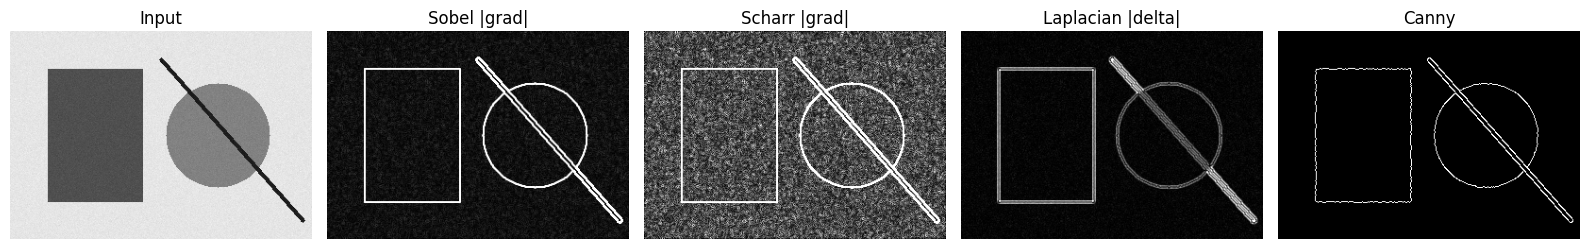

Sobel/Scharr give thick, magnitude-valued edges.
Canny gives THIN binary edges - that's why it's the default for downstream tasks.


In [7]:
# Make a richer scene so edge detection has something to chew on
H, W = 220, 320
scene = np.full((H, W), 230, dtype=np.uint8)
cv2.rectangle(scene, (40, 40), (140, 180), 80, -1)
cv2.circle(scene, (220, 110), 55, 130, -1)
cv2.line(scene, (160, 30), (310, 200), 30, 3)
# Add slight noise so we see noise sensitivity
scene = np.clip(scene + np.random.normal(0, 4, scene.shape), 0, 255).astype(np.uint8)

# 1. Sobel
sx = cv2.Sobel(scene, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(scene, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.clip(np.sqrt(sx**2 + sy**2), 0, 255).astype(np.uint8)

# 2. Scharr
scx = cv2.Scharr(scene, cv2.CV_64F, 1, 0)
scy = cv2.Scharr(scene, cv2.CV_64F, 0, 1)
scharr_mag = np.clip(np.sqrt(scx**2 + scy**2), 0, 255).astype(np.uint8)

# 3. Laplacian (smooth first - it amplifies noise)
smoothed = cv2.GaussianBlur(scene, (3, 3), 1.0)
lap = cv2.Laplacian(smoothed, cv2.CV_64F, ksize=3)
lap_vis = np.clip(np.abs(lap), 0, 255).astype(np.uint8)

# 4. Canny
canny = cv2.Canny(scene, threshold1=60, threshold2=160)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
images = [scene, sobel_mag, scharr_mag, lap_vis, canny]
titles = ["Input", "Sobel |grad|", "Scharr |grad|", "Laplacian |delta|", "Canny"]
for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Sobel/Scharr give thick, magnitude-valued edges.")
print("Canny gives THIN binary edges - that's why it's the default for downstream tasks.")

### 4.1 - Inside Canny: the 4 steps that make it the gold standard

```
1. Gaussian blur                      -> reduce noise
2. Sobel gradient (Gx, Gy)            -> magnitude + direction
3. Non-maximum suppression (NMS)      -> thin thick edges to 1 pixel
4. Double thresholding + hysteresis   -> keep strong edges, link weak ones to strong ones
```

Tuning the two thresholds is where the art lives:

- **High threshold** = "definitely an edge"
- **Low threshold** = "possible edge - only kept if connected to a strong one"
- A common heuristic: `low = high / 2` or `low = high / 3`.


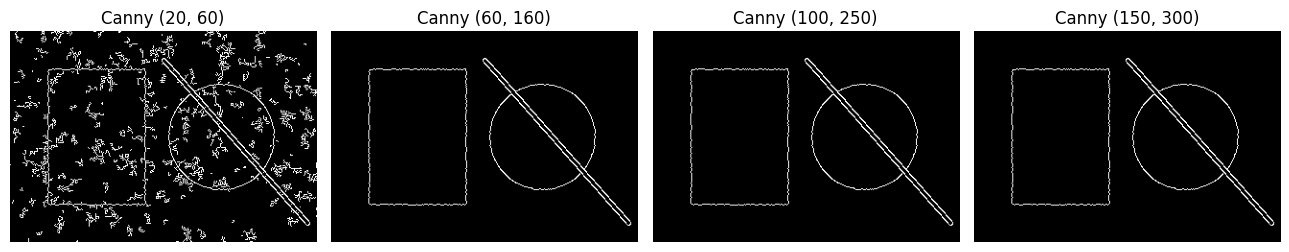

Lower thresholds  -> more (potentially noisy) edges.
Higher thresholds -> fewer, more confident edges.


In [8]:
# Visualize how Canny thresholds change the result
thresholds = [(20, 60), (60, 160), (100, 250), (150, 300)]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, (lo, hi) in zip(axes, thresholds):
    edges = cv2.Canny(scene, lo, hi)
    ax.imshow(edges, cmap="gray")
    ax.set_title(f"Canny ({lo}, {hi})")
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Lower thresholds  -> more (potentially noisy) edges.")
print("Higher thresholds -> fewer, more confident edges.")

## 5. Morphological Operations - Surgery on Binary Images

Morphology operates on binary (or grayscale) images using a *structuring element* (a small kernel - usually a 3x3 square or a disk). It's the toolkit for cleaning up masks after thresholding or segmentation.

### The five core operations

| Operation | Formula | Effect |
|---|---|---|
| **Erosion** | $A \ominus B$ | Shrinks white regions; removes thin protrusions and small specks |
| **Dilation** | $A \oplus B$ | Grows white regions; closes small holes |
| **Opening** | erosion -> dilation | Removes small white noise, preserves shape size |
| **Closing** | dilation -> erosion | Fills small black holes inside white objects |
| **Gradient** | dilation - erosion | One-pixel-wide outline of objects |
| **Top-hat** | input - opening | Highlights small bright details |
| **Black-hat** | closing - input | Highlights small dark details |

### Mnemonic

- **Open** = "open a hole" -> removes small white dots
- **Close** = "close a hole" -> fills small black holes


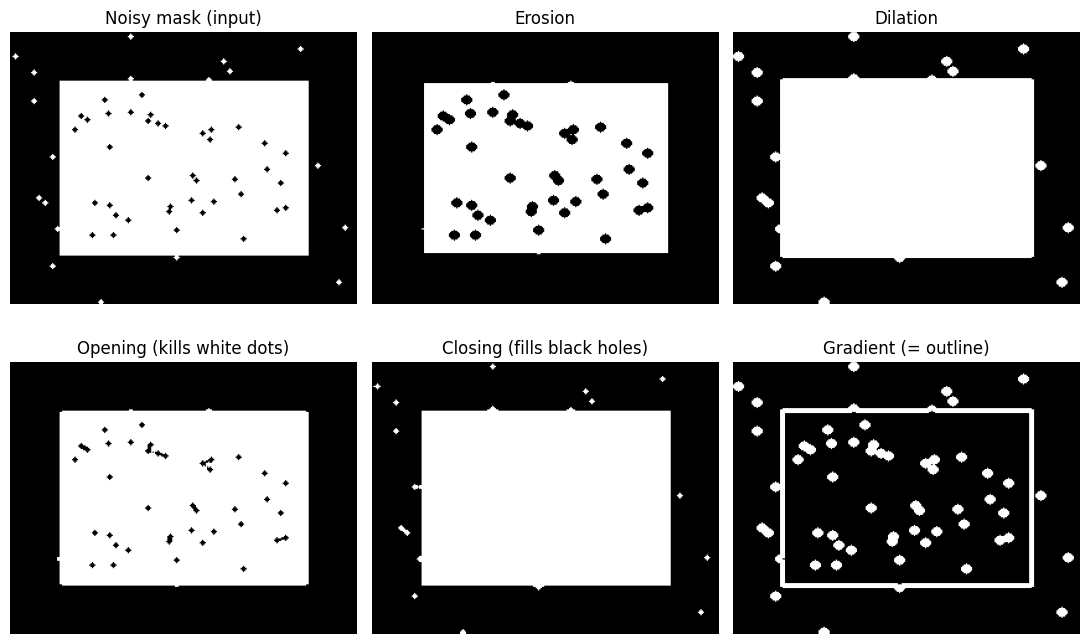

In [9]:
# Build a binary mask with both small noise dots AND small holes - perfect test image
mask = np.zeros((220, 280), dtype=np.uint8)
cv2.rectangle(mask, (40, 40), (240, 180), 255, -1)

# Add 'pepper' noise INSIDE the white region (small black dots)
for _ in range(40):
    cy, cx = np.random.randint(50, 170), np.random.randint(50, 230)
    cv2.circle(mask, (cx, cy), 2, 0, -1)

# Add 'salt' noise OUTSIDE (small white specks)
for _ in range(30):
    cy = np.random.randint(0, 220)
    cx = np.random.randint(0, 280)
    if mask[cy, cx] == 0:
        cv2.circle(mask, (cx, cy), 2, 255, -1)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
eroded = cv2.erode(mask, kernel, iterations=1)
dilated = cv2.dilate(mask, kernel, iterations=1)
opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(mask, cv2.MORPH_GRADIENT, kernel)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
images = [mask, eroded, dilated, opened, closed, gradient]
titles = [
    "Noisy mask (input)", "Erosion", "Dilation",
    "Opening (kills white dots)", "Closing (fills black holes)",
    "Gradient (= outline)",
]
for ax, im, t in zip(axes.ravel(), images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

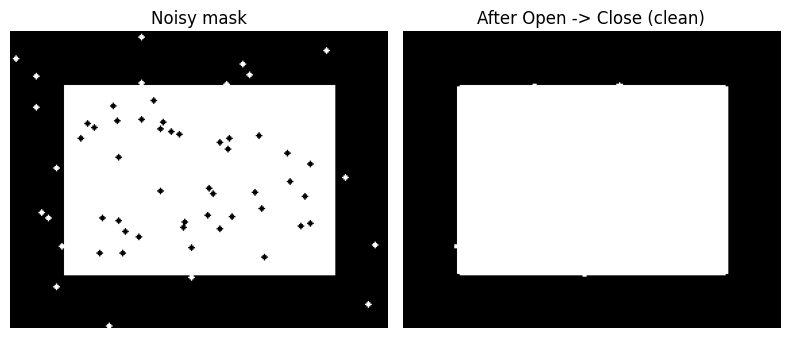

This 2-step combo is the most common 'mask cleanup' pattern in production CV.


In [10]:
# The classic combo: opening THEN closing -> cleans both kinds of noise at once
cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(mask, cmap="gray")
axes[0].set_title("Noisy mask")
axes[1].imshow(cleaned, cmap="gray")
axes[1].set_title("After Open -> Close (clean)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("This 2-step combo is the most common 'mask cleanup' pattern in production CV.")

## 6. Frequency Domain - Seeing Images Through the FFT

Every image can be decomposed into a sum of sinusoids at different frequencies and orientations. The Fourier transform gives you that decomposition.

### Why care?

- Smoothing = removing high frequencies (low-pass filter)
- Sharpening = boosting high frequencies (high-pass)
- Edges and texture live in the high frequencies
- It's also how JPEG works (DCT, a cousin of FFT)

The output is a complex 2D array, usually visualized in log magnitude because the DC component dwarfs everything else.


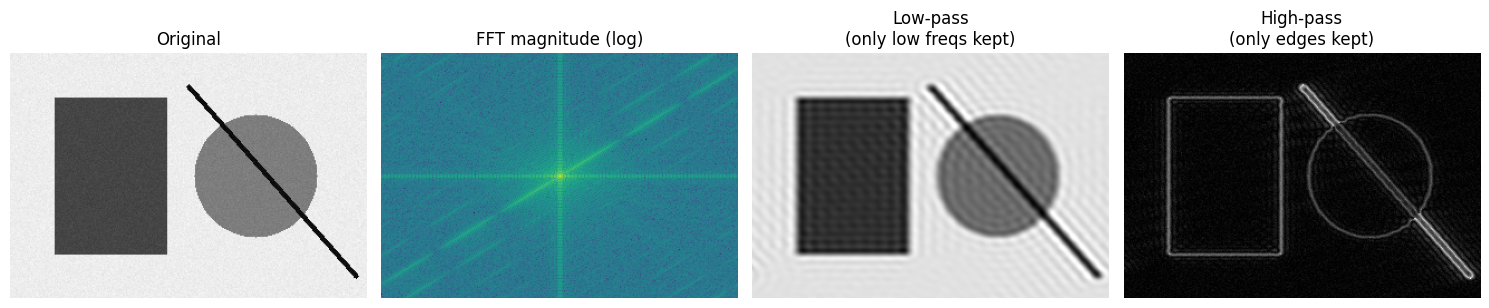

Low-pass = blurry image. High-pass = pure edges. Both are filters in the FREQUENCY domain.


In [11]:
# FFT of our scene - and reconstruct after low-pass / high-pass filtering
f = np.fft.fft2(scene.astype(np.float32))
fshift = np.fft.fftshift(f)   # center the DC component
magnitude = np.log(np.abs(fshift) + 1)

# Build masks centered at DC
H, W = scene.shape
cy, cx = H // 2, W // 2
yy, xx = np.ogrid[:H, :W]
dist = np.sqrt((xx - cx)**2 + (yy - cy)**2)

low_pass_mask = (dist < 30).astype(np.float32)
high_pass_mask = (dist > 30).astype(np.float32)

# Apply, inverse-shift, inverse-FFT
def apply_mask(fshifted, mask):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(fshifted * mask))).astype(np.float32)

img_low = apply_mask(fshift, low_pass_mask)
img_high = apply_mask(fshift, high_pass_mask)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
axes[0].imshow(scene, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(magnitude, cmap="viridis")
axes[1].set_title("FFT magnitude (log)")
axes[2].imshow(np.clip(img_low, 0, 255), cmap="gray")
axes[2].set_title("Low-pass\n(only low freqs kept)")
axes[3].imshow(np.clip(img_high, 0, 255), cmap="gray")
axes[3].set_title("High-pass\n(only edges kept)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Low-pass = blurry image. High-pass = pure edges. Both are filters in the FREQUENCY domain.")

## 7. Capstone - License Plate Cleanup Pipeline

Real-world problem: you've got a noisy, low-contrast, slightly tilted license plate image, and you need to feed clean characters into an OCR engine. This is one of the most classic real applications of everything we learned today.

### The pipeline

```
Raw plate
  | Grayscale
  | CLAHE                       (boost contrast)
  | Bilateral filter            (denoise, keep character edges sharp)
  | Adaptive threshold          (binarize per-region - robust to lighting)
  | Morphological opening       (remove specks)
  | Morphological closing       (fill character holes)
  | Connected components        (extract individual character regions)
  v Cleaned characters (ready for OCR)
```


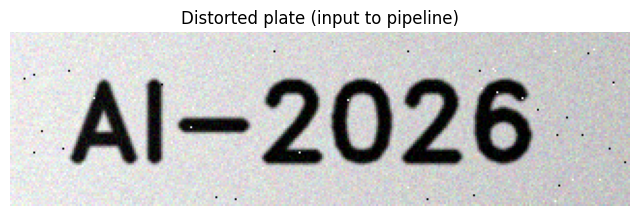

In [12]:
# 1. Synthesize a realistic-ish 'license plate'
plate = np.full((90, 320, 3), 235, dtype=np.uint8)
font = cv2.FONT_HERSHEY_DUPLEX
cv2.putText(plate, "AI-2026", (30, 65), font, 1.8, (20, 20, 20), 4, cv2.LINE_AA)

# 2. Distort: add lighting gradient, blur, noise, and random specks
yy, xx = np.mgrid[0:90, 0:320]
gradient = (40 * (xx / 320)).astype(np.int16)   # brighter on the right
plate_lit = np.clip(plate.astype(np.int16) - gradient[..., None], 0, 255).astype(np.uint8)
plate_blur = cv2.GaussianBlur(plate_lit, (3, 3), 0.8)
noise = np.random.normal(0, 12, plate_blur.shape).astype(np.int16)
plate_noisy = np.clip(plate_blur + noise, 0, 255).astype(np.uint8)

# Add salt-and-pepper specks
for _ in range(60):
    y, x = np.random.randint(0, 90), np.random.randint(0, 320)
    plate_noisy[y, x] = np.random.choice([0, 255])

plt.figure(figsize=(8, 2.5))
plt.imshow(plate_noisy)
plt.title("Distorted plate (input to pipeline)")
plt.axis("off")
plt.show()

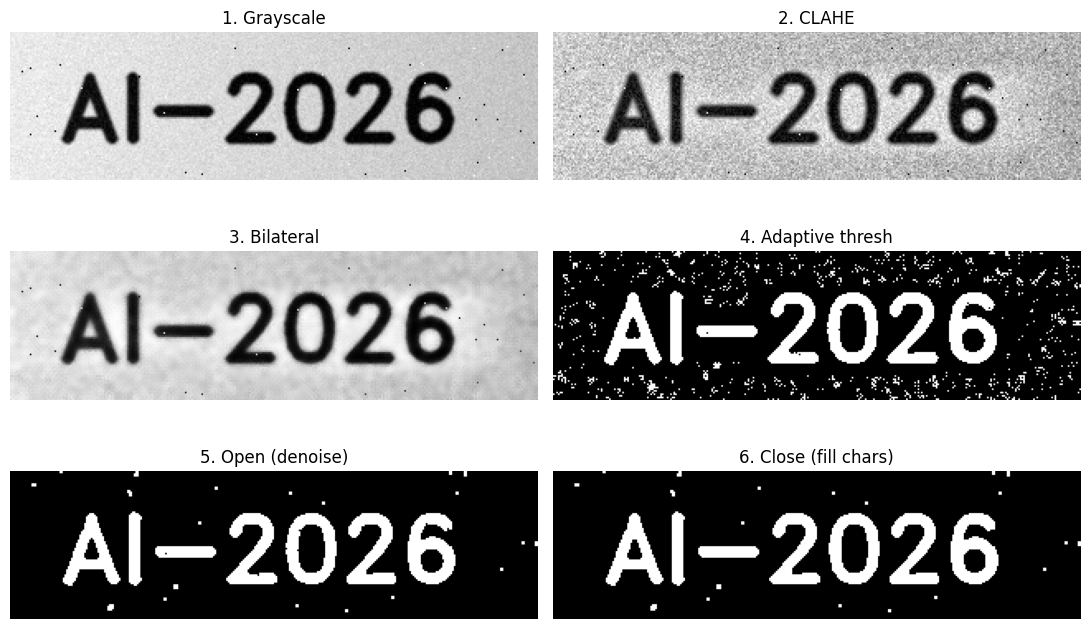

In [13]:
# Run the cleanup pipeline step by step, visualizing every stage
gray = cv2.cvtColor(plate_noisy, cv2.COLOR_RGB2GRAY)

# Step 1: CLAHE for contrast
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
step_clahe = clahe.apply(gray)

# Step 2: Bilateral denoise (keeps character edges sharp)
step_bilat = cv2.bilateralFilter(step_clahe, d=7, sigmaColor=60, sigmaSpace=60)

# Step 3: Adaptive threshold (handles uneven lighting)
step_thresh = cv2.adaptiveThreshold(
    step_bilat, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, blockSize=21, C=8,
)

# Step 4: Open to kill speckle noise
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
step_open = cv2.morphologyEx(step_thresh, cv2.MORPH_OPEN, kernel_open, iterations=1)

# Step 5: Close to merge broken character strokes
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
step_close = cv2.morphologyEx(step_open, cv2.MORPH_CLOSE, kernel_close, iterations=1)

stages = [
    ("1. Grayscale", gray),
    ("2. CLAHE", step_clahe),
    ("3. Bilateral", step_bilat),
    ("4. Adaptive thresh", step_thresh),
    ("5. Open (denoise)", step_open),
    ("6. Close (fill chars)", step_close),
]

fig, axes = plt.subplots(3, 2, figsize=(11, 7))
for ax, (t, im) in zip(axes.ravel(), stages):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

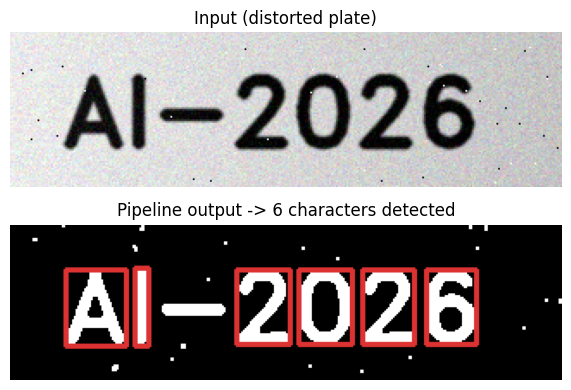

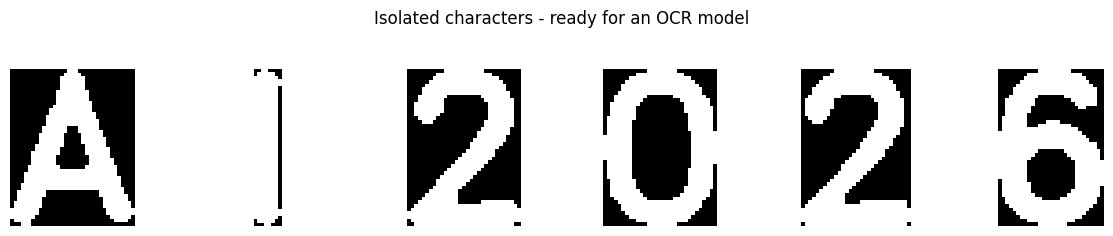

Pipeline complete. Extracted 6 character regions.
In a real system, each crop would now be passed to a CNN/transformer-based OCR head.


In [14]:
# Step 6: Connected-components -> extract individual character bounding boxes
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(step_close, connectivity=8)

# Filter out tiny noise components and the background
char_boxes = []
H_plate = step_close.shape[0]
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    # Heuristics: a character is taller than wide (or comparable),
    # a reasonable height, and a reasonable area
    if area > 80 and h > H_plate * 0.3 and h < H_plate * 0.95 and w < H_plate:
        char_boxes.append((x, y, w, h))

# Sort left-to-right
char_boxes.sort(key=lambda b: b[0])

# Visualize the detected characters on top of the cleaned plate
result = cv2.cvtColor(step_close, cv2.COLOR_GRAY2RGB)
for (x, y, w, h) in char_boxes:
    cv2.rectangle(result, (x, y), (x+w, y+h), (220, 50, 50), 2)

fig, axes = plt.subplots(2, 1, figsize=(9, 4))
axes[0].imshow(plate_noisy)
axes[0].set_title("Input (distorted plate)")
axes[0].axis("off")
axes[1].imshow(result)
axes[1].set_title(f"Pipeline output -> {len(char_boxes)} characters detected")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Show each isolated character - these would be the input to an OCR model
fig, axes = plt.subplots(1, max(len(char_boxes), 1), figsize=(min(12, 2*len(char_boxes)), 2.2))
if len(char_boxes) == 1:
    axes = [axes]
for ax, (x, y, w, h) in zip(axes, char_boxes):
    crop = step_close[y:y+h, x:x+w]
    ax.imshow(crop, cmap="gray")
    ax.axis("off")
plt.suptitle("Isolated characters - ready for an OCR model", y=1.05)
plt.tight_layout()
plt.show()

print(f"Pipeline complete. Extracted {len(char_boxes)} character regions.")
print("In a real system, each crop would now be passed to a CNN/transformer-based OCR head.")

## 8. Recap

- **Convolution** - the one operation behind every classical filter and every CNN
- **Smoothing** - Mean, Gaussian, Median, Bilateral, with clear use-case rules
- **The median trick** - defeats salt-and-pepper noise where Gaussian fails
- **Bilateral** - the only smoother that preserves edges (skin smoothing, denoising)
- **Sharpening** - direct kernels and the unsharp-masking method photographers use
- **Edge detection** - Sobel/Scharr (1st derivative), Laplacian (2nd), Canny (gold standard)
- **Morphology** - erode/dilate/open/close to clean up binary masks
- **Frequency domain** - saw images through the FFT lens, did low/high-pass filtering
- **Capstone** - built a real license-plate cleanup pipeline using everything above

### One-line takeaway

> **Classical filtering isn't dead - it's the indispensable preprocessing layer that makes modern deep models actually work on real-world data.**

---

### Coming next: Notebook 04 - Feature Detection (SIFT, ORB, Harris)

We'll go deep on:

- What makes a "good" keypoint (corners, blobs, scale-invariance)
- **Harris** corner detector - the geometric foundation
- **SIFT** - scale-invariant features, the algorithm that powered a decade of CV
- **ORB** - the fast, free, modern alternative
- Feature matching between images (brute-force, FLANN, ratio test)
- Mini project: stitch two images into a panorama with feature matching

---

<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 100%);padding:18px;border-radius:10px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;margin-top:18px;">
<b>End of Notebook 03 - Computer Vision Series - 2025-2026</b><br>
<span style="opacity:0.8;font-size:13px;">Filters mastered. Next stop: features that survive scale, rotation, and lighting.</span>
</div>